# Chapter 11: Measuring Change

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter11_Delta_Radiomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Every measurement so far described a single scan. But the questions clinicians actually ask are
about change: is the tumor responding, is the muscle wasting, is the damage progressing?

Measuring change sounds like subtraction, and it is — **delta radiomics** is exactly
`feature(after) − feature(before)`. What makes it interesting is that the subtraction has a
property single measurements lack: each patient acts as their own control. Scanner, body size and
anatomy largely cancel, leaving the part that moved.

What makes it hard is that the noise does not cancel. Segment an organ twice and you get two
slightly different outlines, and their difference looks exactly like change.

By the end you will be able to:

1. Build a feature table indexed by patient *and* timepoint.
2. Compute delta features with `qradiomics.delta`.
3. **Measure your own noise floor** using an organ that should not have changed.
4. Say whether an observed change is larger than that floor — the only thing that makes it a finding.

### Before you start

| | |
|---|---|
| **Builds on** | Chapter 9 (what a feature is) and Chapter 10 (why registration matters here) |
| **Downloads** | Two CT timepoints for each of six ACRIN patients — several hundred MB |
| **Longest wait** | Section 1, by a wide margin. It downloads that cohort *and* runs a segmentation network twelve times: measured at **about 50 minutes** on a CPU-only machine with the scans already downloaded |
| **Beyond the setup cell** | `pyradiomics` (from git), `qradiomics`, `SimpleITK`, `TotalSegmentator` |
| **Hardware** | **Use a GPU runtime.** Twelve segmentation runs is where the time goes |

That makes it the slowest cell in Part III to *run* — six times Chapter 12's whole runtime — as
opposed to Chapter 9's, which is the slowest to download. Start it, then read sections 2 and 3
while it works.

The chapter deliberately does **not** register the two timepoints. That is not an oversight — the
whole point is to measure what independent re-segmentation costs you, so that Chapter 10's machinery
has a number attached to what it saves.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import subprocess
import sys

# pyradiomics is the default extraction engine, and an optional extra of
# qradiomics: PyPI ships no wheel for Python 3.10+, so it comes from git.
# The commit is pinned because master moves and the feature values move with
# it — an unpinned install makes this chapter's numbers depend on the day.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pyradiomics @ git+https://github.com/AIM-Harvard/"
                "pyradiomics.git@8ed579383b44806651c463d5e691f3b2b57522ab",
                "qradiomics", "SimpleITK"], check=True)
print("installed")

installed


In [3]:
import collections
import pathlib
import urllib.parse
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk

import medimage_data as md

WORK = pathlib.Path("work/delta")
WORK.mkdir(parents=True, exist_ok=True)

N_PATIENTS = 6

## 1. A cohort with two timepoints

ACRIN 6668 scanned patients before and after chemoradiotherapy. We take the abdominal CT from each
of two visits for a handful of patients.

Two organs are segmented on every scan: the **heart**, and the **liver** as a control. More on why
the control matters shortly.

This cell downloads several hundred megabytes and runs a segmentation network twelve times. Twelve
runs is the whole cost: on a CPU-only machine, with the scans already downloaded, this took **about
50 minutes**. A GPU runtime is strongly advised. Afterwards it reads from the cache and returns in
under a minute.

In [4]:
series = md._get_json(f"{md.NBIA}/getSeries?Collection=ACRIN-NSCLC-FDG-PET")
by_patient = collections.defaultdict(list)
for row in series:
    by_patient[row["PatientID"]].append(row)

cohort = []
for patient, rows in sorted(by_patient.items()):
    dates = sorted({str(r.get("SeriesDate"))[:10] for r in rows if r["Modality"] == "CT"})
    picks = []
    for date in dates:
        candidates = [r for r in rows if r["Modality"] == "CT"
                      and str(r.get("SeriesDate"))[:10] == date
                      and 150 <= int(r["ImageCount"]) <= 450]
        if candidates:
            picks.append(max(candidates, key=lambda r: int(r["ImageCount"])))
    if len(picks) >= 2:
        cohort.append((patient, picks[:2]))
    if len(cohort) >= N_PATIENTS:
        break

print(f"{len(cohort)} patients with two usable CT timepoints")
for patient, picks in cohort:
    print(f"  {patient}  {[str(p['SeriesDate'])[:10] for p in picks]}")

6 patients with two usable CT timepoints
  ACRIN-NSCLC-FDG-PET-001  ['1960-01-10', '1960-07-22']
  ACRIN-NSCLC-FDG-PET-002  ['1960-01-24', '1960-05-31']
  ACRIN-NSCLC-FDG-PET-003  ['1959-12-25', '1960-03-18']
  ACRIN-NSCLC-FDG-PET-005  ['1960-01-24', '1960-07-04']
  ACRIN-NSCLC-FDG-PET-006  ['1960-01-24', '1960-02-21']
  ACRIN-NSCLC-FDG-PET-012  ['1960-01-24', '1960-07-15']


In [5]:
import os
import shutil


def totalsegmentator():
    for candidate in [shutil.which("TotalSegmentator"), ".venv-ts/bin/TotalSegmentator"]:
        if candidate and pathlib.Path(candidate).exists():
            return candidate
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "TotalSegmentator"], check=True)
    return shutil.which("TotalSegmentator")


def segment(nifti, outdir):
    # Jupyter's MPLBACKEND breaks a TotalSegmentator installed in its own venv.
    env = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
    subprocess.run([totalsegmentator(), "-i", str(nifti), "-o", str(outdir),
                    "--roi_subset", "liver", "heart"], check=False, env=env,
                   capture_output=True)


for patient, picks in cohort:
    short = patient.rsplit("-", 1)[-1]
    for timepoint, meta in enumerate(picks):
        tag = f"{short}_tp{timepoint}"
        nifti, segdir = WORK / f"{tag}.nii.gz", WORK / f"{tag}_seg"
        if not nifti.exists():
            folder = md.CACHE / "acrin" / f"{short}_CTx_{timepoint}"
            if not folder.is_dir() or not any(folder.glob("*.dcm")):
                archive = folder.with_suffix(".zip")
                archive.parent.mkdir(parents=True, exist_ok=True)
                md._download(f"{md.NBIA}/getImage?SeriesInstanceUID="
                             f"{urllib.parse.quote(meta['SeriesInstanceUID'])}", archive)
                folder.mkdir(parents=True, exist_ok=True)
                with zipfile.ZipFile(archive) as zf:
                    zf.extractall(folder)
                archive.unlink()
            reader = sitk.ImageSeriesReader()
            reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(folder)))
            sitk.WriteImage(reader.Execute(), str(nifti))
        if not (segdir / "liver.nii.gz").exists():
            segment(nifti, segdir)

ready = sorted(p.name for p in WORK.glob("*_seg") if (p / "liver.nii.gz").exists())
print(f"{len(ready)} scans segmented")

12 scans segmented


## 2. A table indexed by patient and timepoint

Delta features need each row identified by *who* and *when*. The unit being tracked here is a
patient–organ pair, so `001_liver` at `tp0` and `tp1` form one comparison.

In [6]:
rows = []
for nifti in sorted(WORK.glob("*_tp*.nii.gz")):
    tag = nifti.name.replace(".nii.gz", "")
    subject, timepoint = tag.rsplit("_tp", 1)
    for organ in ("liver", "heart"):
        mask = WORK / f"{tag}_seg" / f"{organ}.nii.gz"
        if mask.exists():
            rows.append(dict(unit=f"{subject}_{organ}", timepoint=f"tp{timepoint}",
                             organ=organ, subject=subject,
                             image_path=str(nifti.resolve()), mask_path=str(mask.resolve())))

manifest = pd.DataFrame(rows)
manifest["row_id"] = manifest.unit + "_" + manifest.timepoint
manifest.to_csv(WORK / "manifest_full.csv", index=False)

# qr extract keys on patient_id, so each extraction row needs a unique one.
(manifest.assign(patient_id=manifest.row_id, modality="CT")
         [["patient_id", "modality", "image_path", "mask_path"]]
         .to_csv(WORK / "extract_manifest.csv", index=False))

print(manifest.groupby(["organ", "timepoint"]).size().to_string())

organ  timepoint
heart  tp0          6
       tp1          6
liver  tp0          6
       tp1          6


In [7]:
features_raw = WORK / "features_raw.csv"
if not features_raw.exists():
    subprocess.run(["qr", "extract", "-m", str(WORK / "extract_manifest.csv"),
                    "-o", str(features_raw), "-j", "4"], check=True, capture_output=True)

features = (pd.read_csv(features_raw)
            .merge(manifest[["row_id", "unit", "timepoint", "organ", "subject"]],
                   left_on="patient_id", right_on="row_id")
            .drop(columns=["patient_id", "row_id"])
            .rename(columns={"unit": "patient_id"}))
features["roi_name"] = features.organ

feature_columns = [c for c in features.columns if c.startswith("original_")]
print(f"{len(features)} rows, {len(feature_columns)} features, "
      f"{features.patient_id.nunique()} patient-organ units")

24 rows, 107 features, 12 patient-organ units


## 3. Subtracting

`qradiomics.delta` does the pairing. A `DeltaPair` names the two timepoints, and `compute_delta`
returns one row per unit with a `delta_` column for every feature.

(The `qr delta` command-line wrapper is out of step with this API in the version used here — it
passes argument names the library no longer has — so we call the library directly.)

In [8]:
from qradiomics.delta import DeltaPair, compute_delta

deltas = compute_delta(features, DeltaPair(early="tp0", late="tp1"),
                       feature_cols=feature_columns)
deltas.to_csv(WORK / "delta.csv", index=False)

print(f"delta table: {deltas.shape[0]} units x {deltas.shape[1] - 2} delta features")
print()
show = ["patient_id", "delta_original_shape_MeshVolume",
        "delta_original_firstorder_Mean", "delta_original_glcm_Contrast"]
print(deltas[[c for c in show if c in deltas.columns]].round(1).to_string(index=False))

delta table: 12 units x 107 delta features

patient_id  delta_original_shape_MeshVolume  delta_original_firstorder_Mean  delta_original_glcm_Contrast
 002_heart                           4046.4                             0.2                          -0.0
 001_heart                          80776.8                            19.7                           0.0
 002_liver                          59596.2                            -1.7                           0.1
 001_liver                         121393.1                            24.1                          -0.1
 003_heart                         -13937.3                            -2.5                          -0.3
 003_liver                        -352026.4                             4.4                          -0.1
 005_heart                          13104.0                           -11.5                          -0.2
 006_heart                         -24703.6                           154.9                           2.6
 0

Numbers, one per organ per patient. Some are large. The temptation is to start correlating them
with outcome.

Do not, yet. Nothing so far says whether a change of that size means anything.

## 4. The control organ

Here is the question that decides whether any of this is usable: **how large a change does this
pipeline report for something that did not change?**

The liver is a reasonable control. Over the months between these scans it is not the treatment
target, and in the absence of disease there it should be substantially the same organ. Whatever
delta we measure on the liver is therefore mostly not biology. It is the sum of everything else:
breathing position, contrast timing, patient posture, and above all the fact that the segmentation
was computed independently on each scan and traced a slightly different boundary each time.

That number is the **noise floor**, and no change smaller than it can be believed.

In [9]:
baseline = features[features.timepoint == "tp0"].set_index("patient_id")

def relative_change(organ):
    subset = deltas[deltas.patient_id.str.endswith(organ)]
    out = {}
    for column in feature_columns:
        delta_column = f"delta_{column}"
        if delta_column not in subset.columns:
            continue
        before = baseline.loc[subset.patient_id, column].to_numpy(dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            out[column] = float(np.nanmedian(np.abs(subset[delta_column].to_numpy()) /
                                             np.abs(before)))
    return pd.Series(out)


liver_change = relative_change("liver")
heart_change = relative_change("heart")

print(f"median |change| relative to the starting value")
print(f"  liver (control, should be ~unchanged) : {liver_change.median():6.1%}")
print(f"  heart (the organ of interest)         : {heart_change.median():6.1%}")

median |change| relative to the starting value
  liver (control, should be ~unchanged) :  17.2%
  heart (the organ of interest)         :  16.7%


### Read those two numbers together

The liver — an organ with no reason to have changed — reports a **17% median change**. That is the
floor. It is what this pipeline produces from nothing.

The heart reports about the same. Whatever genuinely happened to the heart between these two scans
is smaller than the noise, or indistinguishable from it at this cohort size.

Reporting the heart number alone would have looked like a result. The control is what tells you
whether it is one.

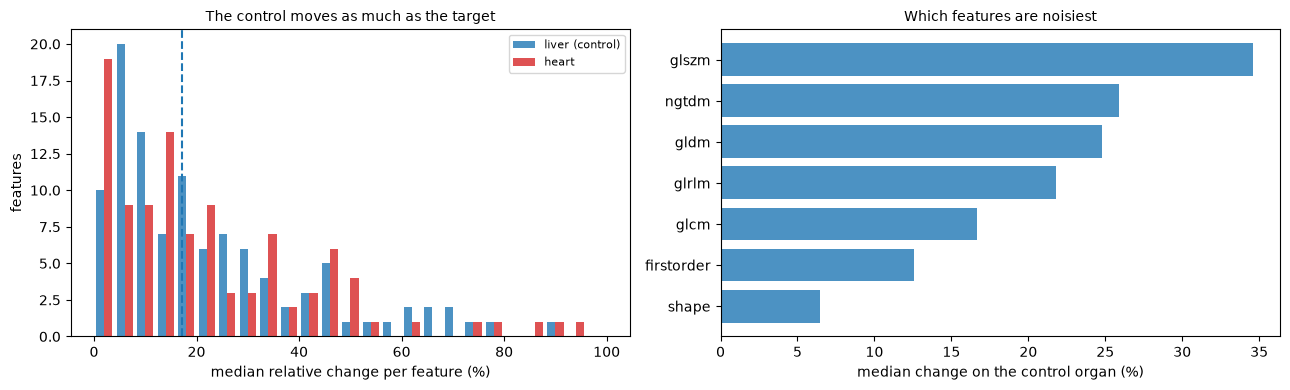

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist([liver_change.dropna() * 100, heart_change.dropna() * 100], bins=25,
             range=(0, 100), label=["liver (control)", "heart"],
             color=["tab:blue", "tab:red"], alpha=0.8)
axes[0].axvline(liver_change.median() * 100, color="tab:blue", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("median relative change per feature (%)")
axes[0].set_ylabel("features")
axes[0].set_title("The control moves as much as the target", fontsize=10)
axes[0].legend(fontsize=8)

family = {}
for column in feature_columns:
    kind = column.split("_")[1]
    family.setdefault(kind, []).append(liver_change.get(column, np.nan))
order = sorted(family, key=lambda k: -np.nanmedian(family[k]))
axes[1].barh(order[::-1], [np.nanmedian(family[k]) * 100 for k in order][::-1],
             color="tab:blue", alpha=0.8)
axes[1].set_xlabel("median change on the control organ (%)")
axes[1].set_title("Which features are noisiest", fontsize=10)

plt.tight_layout()
plt.show()

The right-hand panel should look familiar. The families that move most on an organ that did not
change are the same texture families Chapter 9 showed collapsing when the bin width changed. Shape
features are the steadiest here too.

The reason is the same in both chapters: texture is computed over discretized voxel neighborhoods,
so it inherits every small difference in how the region was drawn and how the intensities were
binned. Shape depends only on the boundary, and boundaries are what segmentation gets most nearly
right.

## 5. What this means for a real study

Delta radiomics is not wrong. It is a genuinely better idea than comparing absolute values across
patients, because it removes the between-patient variation that swamps everything else.

But it only works when the change you are after is bigger than the change your pipeline invents.
Three things follow.

**Measure the floor, always.** Pick a structure that should be stable, run the whole pipeline on it,
and report the number. A study that reports delta features without a control has not established
that its deltas mean anything.

**Segment once where you can.** Most of the floor here comes from re-segmenting independently at
each timepoint. Registering the scans and propagating a single contour — Chapter 10's machinery —
removes that source entirely, at the cost of assuming the anatomy did not deform.

**Prefer the stable features.** If a texture feature moves 60% on a control organ, a 40% change in a
tumor is not a signal, no matter how good its p-value looks.

## Limitations

- **Six patients.** Enough to measure a floor roughly; not enough to trust its exact value.
- **The liver is an imperfect control.** These are lung cancer patients, and the abdomen was imaged
  for a reason. Metastasis or treatment effect in the liver would inflate the floor.
- **No registration.** By design — the point was to measure what independent re-segmentation costs.
  Chapter 10's tools would reduce it.
- **The scans are months apart** and were not acquired for this purpose; contrast phase and breath
  hold differ.

## Recap

| | |
|---|---|
| **Delta radiomics** | `feature(after) − feature(before)`. Each patient is their own control, so scanner and body size largely cancel |
| **The table** | Indexed by patient *and* timepoint, which is what makes the subtraction well defined |
| **The noise floor** | Run the identical pipeline on an organ that should not have changed. Whatever it reports is change your pipeline invented |
| **A finding** | An observed change *larger than that floor*. Below it, the number means nothing regardless of its p-value |

The three consequences, stated as rules:

- **Measure the floor, always.** A delta study with no control organ has not established that its
  deltas mean anything.
- **Segment once where you can.** Most of the floor here came from re-segmenting independently at
  each timepoint. Registering and propagating a single contour — Chapter 10 — removes that source,
  at the cost of assuming the anatomy did not deform.
- **Prefer the stable features.** Chapter 9 already predicted which ones those are: shape survives,
  texture does not. A texture feature that moves 60% on a control organ cannot support a 40% claim
  about a tumor.

**Next:** Chapter 12 takes a feature table and asks a yes-or-no clinical question of it — and runs
into a different way of fooling yourself, one that produces a perfect score instead of a noisy one.

## Exercises

1. Compute the floor separately for shape features and for texture features. How different are the
   two answers, and which would you build a study on?

   *Hint:* the feature names carry their family, so `shape` and `glcm` can be selected by matching
   on the column name. Chapter 9 predicts the direction of the result — this exercise measures it on
   an organ that genuinely did not change.

2. Register each patient's second scan to the first using Chapter 10's method, propagate the
   baseline liver mask instead of re-segmenting, and re-measure the floor. How much does it drop?

   *Hint:* the most valuable exercise in the chapter, and the longest. Propagate with `order=0`.
   What remains after the drop is the floor from acquisition alone — breathing, contrast phase,
   scanner — which registration cannot remove.

3. Add a third control — the spleen, say — and check whether the two controls agree. If they do not,
   what does that tell you?

   *Hint:* the limitations already name the suspect — these are lung cancer patients and the liver
   is a common metastatic site. Two controls disagreeing means at least one is not a control, so
   this is a check on the study design rather than on the code.

4. `compute_trend` fits a slope across more than two timepoints. What extra assumption does a linear
   trend make that a simple difference does not?

   *Hint:* a difference is agnostic about the path between the two points; a slope asserts the
   change is steady. Consider a tumor that shrinks then regrows to its starting size — the
   difference reports zero, and so does the slope, for different reasons and with different
   consequences.

## References

- Fave X, Zhang L, Yang J, et al. *Delta-radiomics features for the prediction of patient outcomes
  in non-small cell lung cancer.* Scientific Reports. 2017;7:588.
- Zwanenburg A, Vallières M, Abdalah MA, et al. *The Image Biomarker Standardization Initiative.*
  Radiology. 2020;295(2):328–338.
- Traverso A, Wee L, Dekker A, Gillies R. *Repeatability and reproducibility of radiomic features: a
  systematic review.* Int J Radiat Oncol Biol Phys. 2018;102(4):1143–1158.
- Machtay M, Duan F, Siegel BA, et al. *ACRIN 6668/RTOG 0235 trial.* J Clin Oncol.
  2013;31(30):3823–3830.